# Driver Drowsiness Detection
## Image Preprocessing

This notebook prepares the manifest-defined driver drowsiness
dataset for deep learning.

The dataset contains two classes:

- Active
- Fatigue

The preprocessing pipeline includes:

- Manifest loading
- Label preparation
- Aspect-ratio-preserving resizing
- Padding
- Data augmentation
- Normalization
- PyTorch Dataset creation
- DataLoader creation

In [1]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.14.0+cu130
CUDA available: True


In [2]:
DATA_DIR = Path(r"E:\Driver-Drowsiness\data\raw")

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Dataset:", DATA_DIR)
print("Dataset exists:", DATA_DIR.exists())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Dataset: E:\Driver-Drowsiness\data\raw
Dataset exists: True
Device: cuda
GPU: NVIDIA GeForce RTX 3050 4GB Laptop GPU


In [3]:
def load_manifest(split):
    txt_path = DATA_DIR / f"{split}.txt"

    records = []

    with open(txt_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            parts = line.split()

            image_path = DATA_DIR / parts[0]
            label = int(parts[-1])

            records.append({
                "path": str(image_path),
                "label": label,
                "class": "active" if label == 0 else "fatigue"
            })

    return pd.DataFrame(records)

In [4]:
train_df = load_manifest("train")
val_df = load_manifest("val")
test_df = load_manifest("test")

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df))

Train: 6384
Validation: 1715
Test: 909
Total: 9008


In [5]:
print("Training distribution:")
print(train_df["class"].value_counts())

print("\nValidation distribution:")
print(val_df["class"].value_counts())

print("\nTest distribution:")
print(test_df["class"].value_counts())

Training distribution:
class
active     3192
fatigue    3192
Name: count, dtype: int64

Validation distribution:
class
active     912
fatigue    803
Name: count, dtype: int64

Test distribution:
class
active     456
fatigue    453
Name: count, dtype: int64


In [6]:
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.85, 1.0),
        ratio=(0.75, 1.33)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
from torchvision import transforms
from PIL import ImageOps

IMAGE_SIZE = 224


class Letterbox:
    """
    Resize an image while preserving its aspect ratio,
    then pad it to IMAGE_SIZE x IMAGE_SIZE.
    """
    
    def __init__(self, size, fill=(0, 0, 0)):
        self.size = size
        self.fill = fill

    def __call__(self, image):
        image = image.convert("RGB")

        # Preserve aspect ratio
        image.thumbnail((self.size, self.size), Image.Resampling.LANCZOS)

        # Create square canvas
        canvas = Image.new(
            "RGB",
            (self.size, self.size),
            self.fill
        )

        # Center the resized image
        x = (self.size - image.width) // 2
        y = (self.size - image.height) // 2

        canvas.paste(image, (x, y))

        return canvas


train_transform = transforms.Compose([
    Letterbox(IMAGE_SIZE),

    # Mild augmentation
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(
        degrees=8
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


eval_transform = transforms.Compose([
    Letterbox(IMAGE_SIZE),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created successfully!")

Transforms created successfully!


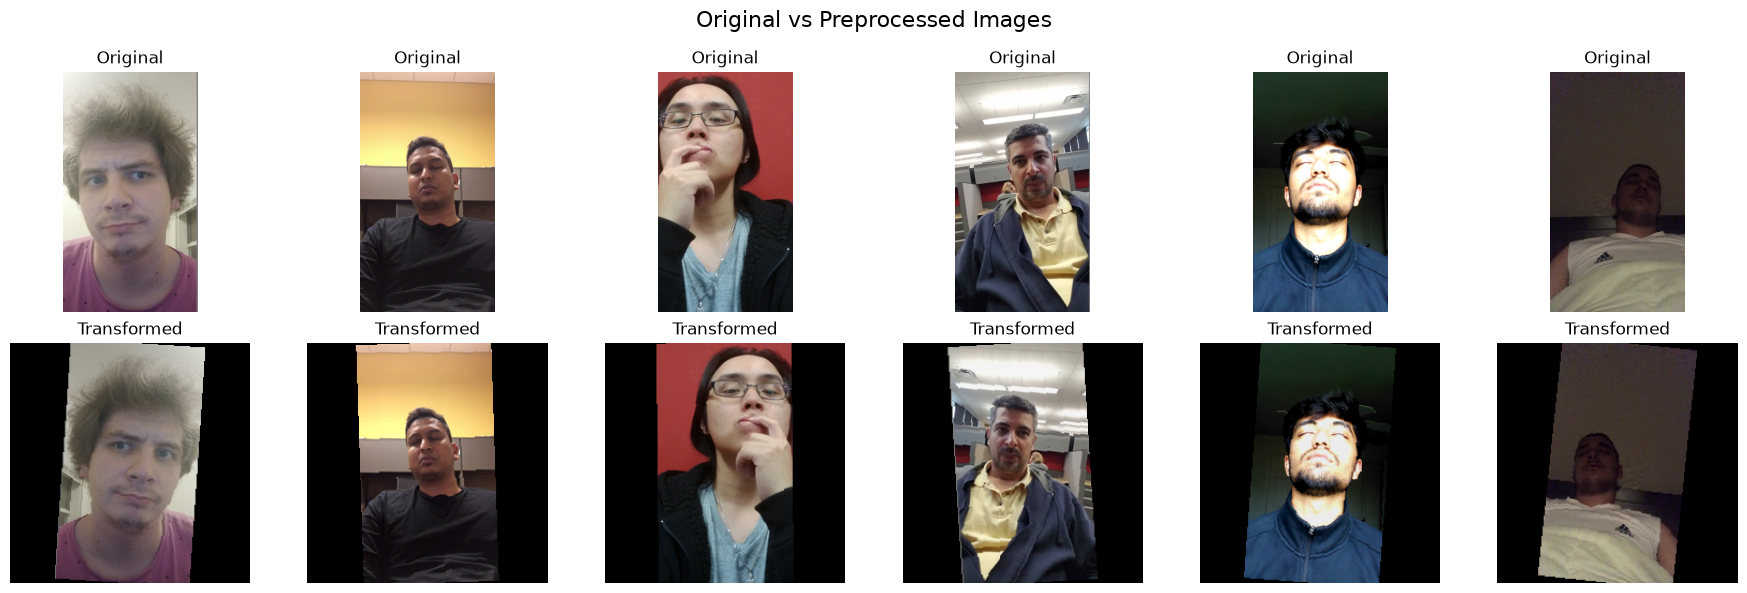

In [10]:
import random

sample_paths = train_df.sample(
    6,
    random_state=42
)["path"].tolist()

fig, axes = plt.subplots(2, 6, figsize=(18, 6))

for i, path in enumerate(sample_paths):

    image = Image.open(path).convert("RGB")

    # Original
    axes[0, i].imshow(image)
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")

    # Transformed
    transformed = train_transform(image)

    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3, 1, 1)

    display_image = transformed * std + mean
    display_image = display_image.clamp(0, 1)

    axes[1, i].imshow(
        display_image.permute(1, 2, 0)
    )

    axes[1, i].set_title("Transformed")
    axes[1, i].axis("off")

plt.suptitle(
    "Original vs Preprocessed Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [11]:
class DrowsinessDataset(Dataset):
    
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = row["path"]
        label = row["label"]

        # Load image
        image = Image.open(image_path).convert("RGB")

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        # Convert label to tensor
        label = torch.tensor(label, dtype=torch.long)

        return image, label

In [12]:
train_dataset = DrowsinessDataset(
    train_df,
    transform=train_transform
)

val_dataset = DrowsinessDataset(
    val_df,
    transform=eval_transform
)

test_dataset = DrowsinessDataset(
    test_df,
    transform=eval_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 6384
Validation dataset: 1715
Test dataset: 909


In [13]:
image, label = train_dataset[0]

print("Tensor shape:", image.shape)
print("Label:", label.item())
print("Tensor dtype:", image.dtype)
print("Tensor minimum:", image.min().item())
print("Tensor maximum:", image.max().item())

Tensor shape: torch.Size([3, 224, 224])
Label: 0
Tensor dtype: torch.float32
Tensor minimum: -2.1179039478302
Tensor maximum: 2.3785624504089355


In [14]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("DataLoaders created!")

DataLoaders created!


In [15]:
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Labels:", labels[:10])

Batch image shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Labels: tensor([0, 1, 0, 1, 1, 1, 1, 0, 0, 1])


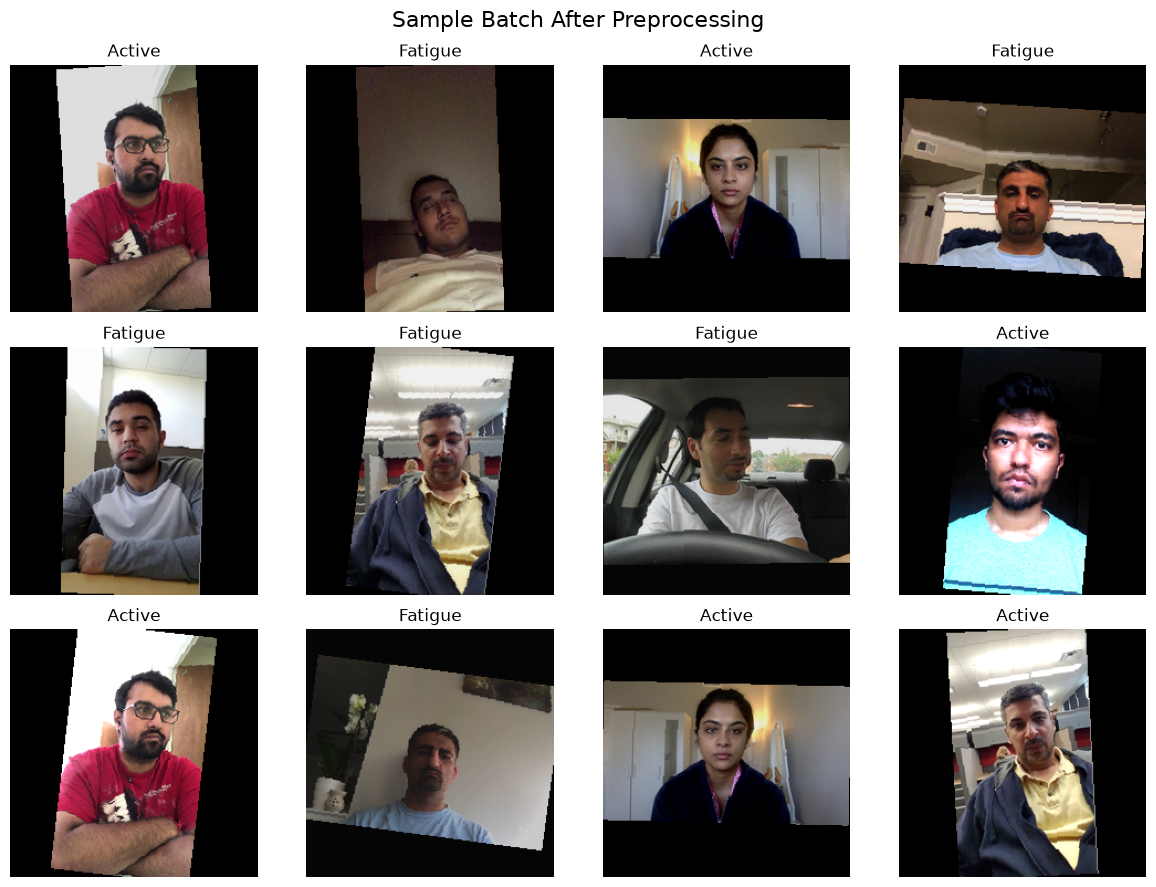

In [16]:
# Undo normalization for visualization

mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)

images_display = images[:12] * std + mean
images_display = images_display.clamp(0, 1)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for i, ax in enumerate(axes.flat):
    
    ax.imshow(
        images_display[i].permute(1, 2, 0)
    )
    
    class_name = "Active" if labels[i].item() == 0 else "Fatigue"
    
    ax.set_title(class_name)
    ax.axis("off")

plt.suptitle(
    "Sample Batch After Preprocessing",
    fontsize=16
)

plt.tight_layout()
plt.show()